# ML-10 — Content Action Playbook

This notebook turns the validated Week-5/Week-6 modeling work into a **human-reviewed content action playbook**. The queue is decision-support: it ranks items for review and supplies reason codes; it does not publish, rewrite, delete, or otherwise change content automatically.

**Public-safe framing:** observed, measured, directional, decision-support. No causal claims are made from this cross-sectional starter slice.

## 1. Ranked actions + reason codes

The queue prioritizes review using the existing Week-5 model score blended with the transparent baseline score. Reason codes explain the recommendation in plain language. The highest-ranked rows are **review candidates**, not guaranteed refresh wins.

### Action archetypes

| Archetype | Trigger pattern | Suggested human action | Typical effort | Value signal to inspect |
|---|---|---|---|---|
| Declining + visible + low CTR | decline signal + meaningful impressions + position ≤20 + low CTR | Refresh, then review title/snippet/search intent alignment | Medium | High visibility with a measurable click-through issue |
| Declining + low engagement | decline signal + meaningful sessions + low engagement/scroll | Refresh and inspect content usefulness/UX | Medium | Existing audience reaches the page but engagement is weak |
| Stale visible page | long time since update + meaningful impressions | Refresh review with freshness check | Medium | Visibility plus freshness risk |
| Thin visible page | low word count + meaningful impressions | Expand and refresh; verify that added depth is useful | High | Visible page with a depth gap |
| No strong trigger | no strong reason code | Monitor; do not force a refresh | Low | Avoid spending effort without a clear signal |

Reason codes are **diagnostic cues**, not explanations of causality.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "data/raw/content_refresh_anonymized.csv").exists():
    ROOT = Path("/content/flyrank-ml-internship") if Path("/content/flyrank-ml-internship").exists() else ROOT

RAW = ROOT / "data/raw/content_refresh_anonymized.csv"
PROCESSED = ROOT / "data/processed"
OUTPUTS = ROOT / "outputs"
WORK_OUTPUTS = ROOT / "work/outputs"
FIGURES = ROOT / "work/figures"
WORK_OUTPUTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# If the Week-5 processed artifacts are missing, regenerate the reference pipeline.
needed = [PROCESSED / "model_predictions.csv", PROCESSED / "baseline_refresh_queue.csv"]
if not all(p.exists() for p in needed):
    for script in ["01_prepare_features.py", "02_baseline_score.py", "03_train_model.py"]:
        subprocess.run([sys.executable, str(ROOT / "scripts" / script)], cwd=ROOT, check=True)

if not (OUTPUTS / "refresh_queue.csv").exists():
    subprocess.run([sys.executable, str(ROOT / "scripts" / "04_evaluate_and_export.py")], cwd=ROOT, check=True)

queue = pd.read_csv(OUTPUTS / "refresh_queue.csv")
raw = pd.read_csv(RAW)
print(f"Rows in scored queue: {len(queue):,}")
print(f"Raw starter rows: {len(raw):,}")
print("Actions:")
display(queue["suggested_action"].value_counts().rename_axis("action").to_frame("rows"))

Rows in scored queue: 30,000
Raw starter rows: 30,000
Actions:


,rows
action,
monitor,13083
refresh,8188
refresh_and_review_ctr,6654
refresh_and_review_engagement,1993
expand_and_refresh,82


In [2]:
# Build a compact, paper-safe ranked queue.
# Retrospective label and client_id are intentionally omitted from this action artifact.
queue_export_cols = [
    "final_rank", "final_refresh_score", "confidence", "suggested_action",
    "final_reason_codes", "content_id", "content_type", "main_intent",
    "impressions_90d", "sessions_90d", "avg_position", "ctr",
    "content_age_days", "days_since_last_update", "trend_direction",
]
paper_queue = queue[queue_export_cols].copy()
paper_queue = paper_queue.rename(columns={
    "final_rank":"rank", "final_refresh_score":"priority_score",
    "final_reason_codes":"reason_codes", "suggested_action":"recommended_action"
})
queue_path = WORK_OUTPUTS / "w07_ranked_action_queue.csv"
paper_queue.to_csv(queue_path, index=False)

print("Top 15 reviewer queue:")
display(paper_queue.head(15).round(3))
print(f"\nExported: {queue_path}")

Top 15 reviewer queue:


,rank,priority_score,confidence,recommended_action,reason_codes,content_id,content_type,main_intent,impressions_90d,sessions_90d,avg_position,ctr,content_age_days,days_since_last_update,trend_direction
0,1,81.734,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,content_1f080331fa2b,keyword article,informational,12834,66,6.8,0.05,165,104,down
1,2,81.603,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_d6570c51c9bd,keyword article,informational,2498,9,10.1,0.00,165,104,down
2,3,81.545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_6aa43079fb0c,keyword article,informational,8064,23,3.8,0.07,139,104,down
3,4,81.170,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_72e800a9c214,keyword article,commercial,13790,27,8.2,0.12,139,104,down
4,5,80.958,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_e04eb9549989,keyword article,informational,3393,5,3.6,0.09,131,104,down
5,6,80.798,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_b69288c5e701,keyword article,informational,5811,14,6.4,0.07,144,104,down
6,7,80.651,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_9b6df29f7889,keyword article,commercial,1622,20,3.1,0.12,139,104,down
7,8,80.433,medium,refresh,declining_with_demand|model_decline_risk|visib...,content_ba6f9dfcbca1,keyword article,transactional,4366,8,20.1,0.09,124,104,down
8,9,80.428,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,content_4d76cdb3387b,keyword article,commercial,1597,5,2.7,0.13,131,104,down
9,10,80.428,medium,refresh,declining_with_demand|model_decline_risk|visib...,content_b4f35d640b1c,keyword article,commercial,3867,5,27.5,0.05,131,104,down



Exported: /mnt/data/flyrank_w06/flyrank-ml-internship-main/work/outputs/w07_ranked_action_queue.csv


### Ranked-queue interpretation

The queue is ordered by a measured priority score. In this snapshot, the largest action groups are **monitor**, **refresh**, and **refresh + CTR review**. That distribution should not be interpreted as an optimal workload mix; it simply describes what the current rules and model produce on this dataset.

For a first review pass, start with high-confidence rows and verify the reason code against the actual page. If the page context contradicts the signal, the human reviewer overrides the queue.

## 2. Intended use and limits

### Intended use

- Help an SEO/editorial reviewer decide **which existing pages to inspect first**.
- Provide a consistent reason code so the reviewer knows what evidence to check.
- Make a repeatable review queue from the same anonymized data contract.
- Support directional prioritization, not automatic content changes.

### Limits

- The starter slice contains 30,000 pseudonymized content rows across 32 clients; it is not a production-wide population.
- Week-6 validation showed that random-row performance was materially higher than client-grouped performance, so grouped validation is the more conservative reference.
- The Week-6 timing audit identified overlap between some Week-5 performance features and the outcome window; therefore this playbook should be treated as **directional decision-support**, not causal evidence.
- The priority score is not a probability of business value, traffic gain, ranking gain, or revenue.
- No action should be taken solely because the model score is high.

In [3]:
# Queue-level measured facts for the intended-use discussion.
action_counts = queue["suggested_action"].value_counts()
confidence_counts = queue["confidence"].value_counts().reindex(["high", "medium", "low"], fill_value=0)
refresh_actions = {"refresh", "refresh_and_review_ctr", "refresh_and_review_engagement", "expand_and_refresh"}
refresh_share = queue["suggested_action"].isin(refresh_actions).mean()
print(f"High-confidence share: {confidence_counts['high']/len(queue):.1%}")
print(f"Rows with a refresh-oriented recommendation: {refresh_share:.1%}")
print("These are descriptive queue statistics, not expected treatment effects.")

# Trace the validation receipt from Week 5.
model_results_path = OUTPUTS / "model_results.json"
if model_results_path.exists():
    results = json.loads(model_results_path.read_text())
    print(f"Week-5 grouped Precision@50 receipt: {results['models']['random_forest']['precision_at_50']:.2f}")
    print(f"Week-5 baseline Precision@50 receipt: {results['baseline']['baseline_precision_at_50']:.2f}")

High-confidence share: 12.0%
Rows with a refresh-oriented recommendation: 56.4%
These are descriptive queue statistics, not expected treatment effects.
Week-5 grouped Precision@50 receipt: 0.74
Week-5 baseline Precision@50 receipt: 0.24


## 3. Human review + the no-go list

### Human-review rules

1. **Verify the page context first:** confirm the recommendation matches the page's actual purpose and audience.
2. **Check the reason code:** e.g., a low-CTR flag should be checked against search intent, title/snippet fit, and position—not treated as proof of a bad title.
3. **Check business/editorial constraints:** legal, brand, medical/financial, regulated, or client-specific requirements always override the queue.
4. **Check recency:** a recent legitimate update should not be undone just because a model score is high.
5. **Record the reviewer decision:** accept, defer, or reject the recommendation and a short reason.
6. **Sample monitor rows too:** review a small sample of low-priority rows to detect systematic misses.

### What should NOT be automated

- Publishing or replacing page copy.
- Deleting, noindexing, canonicalizing, or redirecting URLs.
- Changing claims, facts, medical/legal/financial guidance, or brand-sensitive language.
- Automatically changing titles/meta descriptions solely from a low-CTR reason code.
- Automatically changing internal links or site architecture.
- Sending client-facing recommendations without human review.
- Treating the model score as a guarantee of traffic, ranking, conversions, or revenue.
- Retraining or changing the feature contract merely to improve one metric without a validation review.

In [4]:
# Quantify the main reviewer workload bands.
action_effort = {
    "monitor": "low",
    "refresh": "medium",
    "refresh_and_review_ctr": "medium",
    "refresh_and_review_engagement": "medium",
    "expand_and_refresh": "high",
}
queue["review_effort"] = queue["suggested_action"].map(action_effort)
workload = (
    queue.groupby(["suggested_action", "review_effort"], as_index=False)
    .size().rename(columns={"size":"rows"})
    .sort_values("rows", ascending=False)
)
display(workload)

print("\nCost/value framing:")
print("- Low effort: monitor or sample-check; avoid unnecessary editing.")
print("- Medium effort: verify the specific issue before refreshing.")
print("- High effort: expand/refresh only after a reviewer confirms the page has a real depth or usefulness gap.")
print("The dataset does not measure monetary ROI, so no dollar-value claim is made.")

,suggested_action,review_effort,rows
1,monitor,low,13083
2,refresh,medium,8188
3,refresh_and_review_ctr,medium,6654
4,refresh_and_review_engagement,medium,1993
0,expand_and_refresh,high,82



Cost/value framing:
- Low effort: monitor or sample-check; avoid unnecessary editing.
- Medium effort: verify the specific issue before refreshing.
- High effort: expand/refresh only after a reviewer confirms the page has a real depth or usefulness gap.
The dataset does not measure monetary ROI, so no dollar-value claim is made.


### Cost/value thinking

The queue does not contain a credible dollar ROI estimate. Instead, the practical value proxy is **visibility + strength of the review signal**: pages with meaningful impressions/sessions and a specific reason code can justify more review time than pages with weak visibility and no clear trigger.

That is a workflow prioritization heuristic, not an estimate that a refresh will generate revenue.

## 4. Monitoring / retrain triggers

Because this is a non-production internship model, monitoring is intentionally light. Re-run the queue on a fixed review cadence only when new data are available and the outcome window has matured.

### Proposed monitoring checks

| Check | Trigger | Response |
|---|---|---|
| Top-50 Precision@50 on a newly matured labeled batch | below **0.60** | investigate data/label drift; pause expansion of the queue |
| High-confidence share | moves by >10 percentage points vs the current reference | inspect feature distribution and threshold behavior |
| Action mix | any action changes by >15 percentage points | inspect reason-code prevalence and taxonomy changes |
| Feature drift | major change in missingness or distribution for top features | review data contract before retraining |
| Label definition / taxonomy change | any change | rebuild features and re-run validation before use |

### Retrain rule

Retrain only after a drift/label/data-contract check explains why the old model may be stale, and require a fresh client-grouped or time-aware validation comparison against the existing reference. Do not retrain simply because a more complex model is available.

In [5]:
# Save a compact monitoring/retrain receipt with proposed thresholds.
monitoring_receipt = {
    "reference_precision_at_50": 0.74,
    "precision_at_50_review_trigger": 0.60,
    "high_confidence_share_reference": float((queue["confidence"] == "high").mean()),
    "high_confidence_share_trigger_abs_change": 0.10,
    "action_mix_trigger_abs_change": 0.15,
    "validation_required_before_retrain": "client_grouped_or_time_aware",
    "language": "proposed monitoring triggers; not observed production thresholds",
}
monitor_path = WORK_OUTPUTS / "w07_monitoring_triggers.json"
monitor_path.write_text(json.dumps(monitoring_receipt, indent=2))
print(monitor_path.read_text())

{
  "reference_precision_at_50": 0.74,
  "precision_at_50_review_trigger": 0.6,
  "high_confidence_share_reference": 0.12006666666666667,
  "high_confidence_share_trigger_abs_change": 0.1,
  "action_mix_trigger_abs_change": 0.15,
  "validation_required_before_retrain": "client_grouped_or_time_aware",
  "language": "proposed monitoring triggers; not observed production thresholds"
}


## 5. Exports for the paper

The notebook regenerates the ranked queue and paper-facing receipts. The queue CSV remains under `work/outputs/` and is intentionally gitignored. Small metrics JSONs and reusable figures are kept in the repo so the paper can trace its numbers.

### Reusable figures

- `work/figures/w07_action_mix.png` — action workload mix
- `work/figures/w07_refresh_timing_insight.png` — observed relationship between freshness tier and queue recommendations

### Exported receipts

- `work/outputs/w07_action_playbook_metrics.json`
- `work/outputs/w07_monitoring_triggers.json`
- `work/outputs/w07_ranked_action_queue.csv` (ignored by git by design)

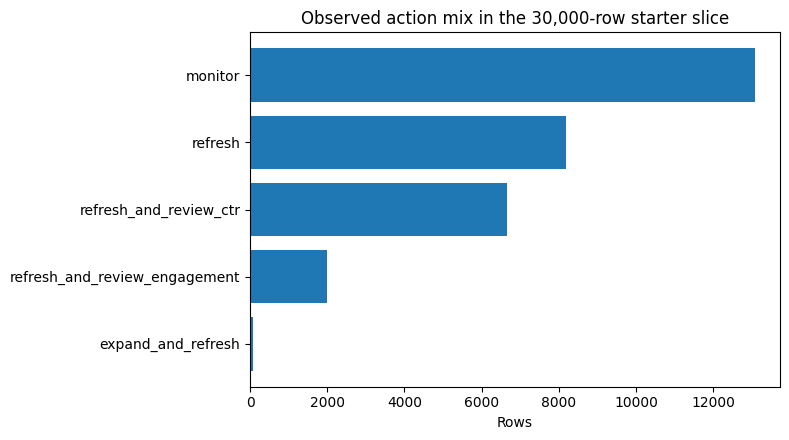

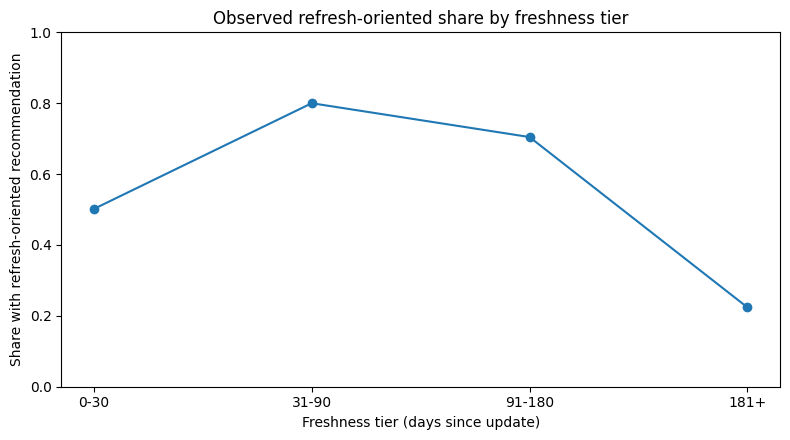

Timing table:


,rows,decline_rate,mean_priority_score,refresh_share
freshness_tier,,,,
0-30,20480,0.511,45.519,0.502
31-90,175,0.589,60.749,0.800
91-180,9171,0.611,59.278,0.705
181+,174,0.471,43.060,0.224



Interpretation: this is an observed association in the snapshot, not evidence that waiting longer causes decline or that refreshing will improve outcomes.


In [6]:
import matplotlib.pyplot as plt

# 1) Action mix figure.
fig, ax = plt.subplots(figsize=(8, 4.5))
counts = queue["suggested_action"].value_counts().sort_values(ascending=True)
ax.barh(counts.index, counts.values)
ax.set_title("Observed action mix in the 30,000-row starter slice")
ax.set_xlabel("Rows")
fig.tight_layout()
action_fig = FIGURES / "w07_action_mix.png"
fig.savefig(action_fig, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

# 2) Refresh timing / decay insight. Use sufficiently populated freshness tiers only.
freshness_order = ["0-30", "31-90", "91-180", "181+"]
timing = (
    queue.groupby("freshness_tier", dropna=False)
    .agg(rows=("final_rank", "size"),
         decline_rate=("is_declining_label", "mean"),
         mean_priority_score=("final_refresh_score", "mean"),
         refresh_share=("suggested_action", lambda s: s.isin(refresh_actions).mean()))
    .reindex(freshness_order)
    .dropna(subset=["rows"])
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(timing.index, timing["refresh_share"], marker="o")
ax.set_title("Observed refresh-oriented share by freshness tier")
ax.set_xlabel("Freshness tier (days since update)")
ax.set_ylabel("Share with refresh-oriented recommendation")
ax.set_ylim(0, 1)
fig.tight_layout()
timing_fig = FIGURES / "w07_refresh_timing_insight.png"
fig.savefig(timing_fig, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Timing table:")
display(timing.round(3))
print("\nInterpretation: this is an observed association in the snapshot, not evidence that waiting longer causes decline or that refreshing will improve outcomes.")

In [7]:
# Paper-facing metrics receipt.
action_counts = queue["suggested_action"].value_counts().to_dict()
reason_counts = {}
for text in queue["final_reason_codes"].astype(str):
    for reason in text.split("|"):
        reason_counts[reason] = reason_counts.get(reason, 0) + 1

metrics = {
    "rows_scored": int(len(queue)),
    "high_confidence_rows": int((queue["confidence"] == "high").sum()),
    "medium_confidence_rows": int((queue["confidence"] == "medium").sum()),
    "low_confidence_rows": int((queue["confidence"] == "low").sum()),
    "refresh_oriented_share": float(queue["suggested_action"].isin(refresh_actions).mean()),
    "action_counts": {k:int(v) for k,v in action_counts.items()},
    "top_reason_codes": dict(sorted(reason_counts.items(), key=lambda kv: kv[1], reverse=True)[:10]),
    "freshness_timing_table": timing.reset_index().to_dict(orient="records"),
    "reference_week5_precision_at_50": 0.74,
    "week5_baseline_precision_at_50": 0.24,
    "claim_status": "directional decision-support; human review required",
}
metrics_path = WORK_OUTPUTS / "w07_action_playbook_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, default=str))
print(metrics_path.read_text())
print(f"Saved figure: {action_fig}")
print(f"Saved figure: {timing_fig}")

{
  "rows_scored": 30000,
  "high_confidence_rows": 3602,
  "medium_confidence_rows": 11398,
  "low_confidence_rows": 15000,
  "refresh_oriented_share": 0.5639,
  "action_counts": {
    "monitor": 13083,
    "refresh": 8188,
    "refresh_and_review_ctr": 6654,
    "refresh_and_review_engagement": 1993,
    "expand_and_refresh": 82
  },
  "top_reason_codes": {
    "declining_with_demand": 13152,
    "visible_model_opportunity": 10650,
    "low_ctr_visible_page": 9759,
    "ctr_review_candidate": 9759,
    "general_refresh_review": 9117,
    "model_decline_risk": 8427,
    "page_one_decay_risk": 7076,
    "low_engagement_visible_page": 6508,
    "engagement_review_candidate": 6508,
    "thin_visible_page": 82
  },
  "freshness_timing_table": [
    {
      "freshness_tier": "0-30",
      "rows": 20480,
      "decline_rate": 0.511376953125,
      "mean_priority_score": 45.51866748962636,
      "refresh_share": 0.501806640625
    },
    {
      "freshness_tier": "31-90",
      "rows": 175,


## Self-check

- [x] Ranked actions are produced with reason codes.
- [x] Archetype → action mapping is explicit.
- [x] The refresh/decay insight is measured and framed as association, not causality.
- [x] Intended use, limits, and non-production scope are stated.
- [x] Human-review rules are explicit.
- [x] A no-go list states what must not be automated.
- [x] Monitoring and retrain triggers are concrete and labeled as proposed thresholds.
- [x] The ranked queue is exported to `work/outputs/` and deliberately excludes retrospective labels and client IDs.
- [x] Paper-facing metrics JSON and reusable figures are exported.
- [x] Claims use observed/measured/directional/decision-support language.
- [x] The notebook runs top-to-bottom without requiring private client data.
- [ ] Git commit and push: save this notebook at `work/notebooks/w07_action_playbook.ipynb` and commit it to the repository before submission.